In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix
import joblib

path    = '../models/lgbm_best_model.pkl'
model   = joblib.load(path)
data    = pd.read_parquet('../data/processed/train_data.parquet')

X = data.drop(columns=['TARGET', "SK_ID_CURR"])
y = data['TARGET']
y_pred_proba = model.predict_proba(X)[:, 1]


Best Threshold (F1-Score): 0.5972 (F1 = 0.6383)
Best Threshold (Min Cost): 0.5051 (Cost = 40219)


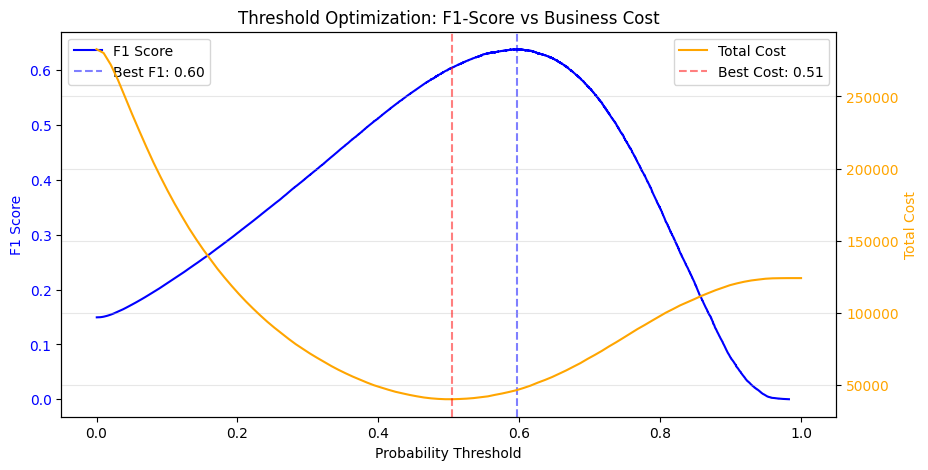

In [6]:
precision, recall, thresholds = precision_recall_curve(y, y_pred_proba)

# Sử dụng np.divide để tránh lỗi chia cho 0 nếu precision + recall = 0
f1_scores = np.divide(2 * (precision * recall), (precision + recall), 
                      out=np.zeros_like(precision), 
                      where=(precision + recall) != 0)

# Lấy best threshold cho F1 (Lưu ý: thresholds ngắn hơn f1_scores 1 phần tử)
# Cắt bỏ phần tử cuối của f1_scores để khớp độ dài với thresholds
best_idx_f1 = np.argmax(f1_scores[:-1]) 
best_threshold_f1 = thresholds[best_idx_f1]
print(f"Best Threshold (F1-Score): {best_threshold_f1:.4f} (F1 = {f1_scores[best_idx_f1]:.4f})")

# 3. Tính toán Total Cost (Tối ưu hóa: Không dùng vòng lặp for)
cost_fn = 5 
cost_fp = 1

# Thay vì lặp qua từng threshold, ta có thể đánh giá trên một mảng 100 điểm phân bố đều
eval_thresholds = np.linspace(0, 1, 100)
costs = []

for t in eval_thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    # Thêm tham số labels=[0, 1] để đảm bảo luôn trả về 4 giá trị kể cả khi model dự đoán lệch hẳn 1 class
    tn, fp, fn, tp = confusion_matrix(y, y_pred_t, labels=[0, 1]).ravel()
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    costs.append(total_cost)

best_idx_cost = np.argmin(costs)
best_threshold_cost = eval_thresholds[best_idx_cost]
print(f"Best Threshold (Min Cost): {best_threshold_cost:.4f} (Cost = {costs[best_idx_cost]})")

# 4. Trực quan hóa
plt.figure(figsize=(10, 5))

# Plot F1-Score (Trục Y trái)
ax1 = plt.gca()
ax1.plot(thresholds, f1_scores[:-1], label='F1 Score', color='blue')
ax1.set_xlabel('Probability Threshold')
ax1.set_ylabel('F1 Score', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot Total Cost (Trục Y phải)
ax2 = ax1.twinx()
ax2.plot(eval_thresholds, costs, label='Total Cost', color='orange')
ax2.set_ylabel('Total Cost', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Thêm đường kẻ dọc cho các ngưỡng tốt nhất
ax1.axvline(best_threshold_f1, color='blue', linestyle='--', alpha=0.5, label=f'Best F1: {best_threshold_f1:.2f}')
ax2.axvline(best_threshold_cost, color='red', linestyle='--', alpha=0.5, label=f'Best Cost: {best_threshold_cost:.2f}')

plt.title('Threshold Optimization: F1-Score vs Business Cost')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()